In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
match_time_df = pd.read_csv("../time.csv")

MIN_SET_SECONDS = 10 * 60
MAX_SET_SECONDS = 150 * 60
MIN_MATCH_SECONDS = 30 * 60
MAX_MATCH_SECONDS = 420 * 60
period_columns = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']
df = match_time_df.copy()
total_original = len(df)

Handle Duplicate match_ids
First, we check the duplicate match_ids to find out if they are corrupt data or interrupted matches.

- Test 1: If the rows are almost identical, we treat them as corrupt duplicates.
- Test 2: If two rows have values for the same set, such as both having a value for period_1, we treat them as overlapping data, not an interrupted match.
- Test 3: We check the timestamps. They should be different because an interrupted match should have different sessions.

If a duplicate passes all three tests, we treat it as an interrupted match.

For interrupted matches:
We merge the rows by taking the first non-null value for each set.
We keep the earliest timestamp as the match's starting time.
Finally, we combine the clean single rows with the resolved interrupted matches.

In [27]:
df = df.drop_duplicates()

single_rows = df[~df['match_id'].duplicated(keep=False)].copy()
duplicate_ids = df[df['match_id'].duplicated(keep=False)].copy()

fixed_interrupted = [] 
corrupt_match_ids = [] 

for match_id, group in duplicate_ids.groupby('match_id'):

    # Test 1
    numeric_columns = [c for c in period_columns if c in group.columns]
    period_values = group[numeric_columns].fillna(-1)
    is_identical = (period_values.nunique() == 1).all()
    if is_identical:
        corrupt_match_ids.append(match_id)
        continue

    # Test 2
    conflict = False
    for col in period_columns:
        non_null_vals = group[col].dropna()
        if len(non_null_vals) > 1:
            conflict = True
            break
    if conflict:
        corrupt_match_ids.append(match_id)
        continue

    # Test 3
    if 'current_period_start_timestamp' in group.columns:
        timestamps = group['current_period_start_timestamp'].dropna().unique()
        if len(timestamps) <= 1:
            corrupt_match_ids.append(match_id)
            continue

    # interrupted match
    merged = {}
    merged['match_id'] = match_id
    for col in period_columns:
        non_null = group[col].dropna()
        merged[col] = non_null.iloc[0] if len(non_null) > 0 else np.nan

    if 'current_period_start_timestamp' in group.columns:
        merged['current_period_start_timestamp'] = (
            group['current_period_start_timestamp'].dropna().min())

    fixed_interrupted.append(merged)

interrupted_df = pd.DataFrame(fixed_interrupted) if fixed_interrupted else pd.DataFrame()
df = pd.concat([single_rows, interrupted_df], ignore_index=True)

n_corrupt = len(corrupt_match_ids)
n_interrupted = len(fixed_interrupted)

In [28]:
cells_nulled_s3 = 0
for col in period_columns:
    invalid_mask = df[col].notna() & (
        (df[col] < MIN_SET_SECONDS) | (df[col] > MAX_SET_SECONDS))
    cells_nulled_s3 += invalid_mask.sum()
    df.loc[invalid_mask, col] = np.nan

In [29]:
before_s4 = len(df)
df = df[df['period_1'].notna() & df['period_2'].notna()]
removed_s4 = before_s4 - len(df)

In [30]:
cells_nulled_s5 = 0
mask_no_p3 = df['period_3'].isna()
cells_nulled_s5 += (mask_no_p3 & df['period_4'].notna()).sum()
cells_nulled_s5 += (mask_no_p3 & df['period_5'].notna()).sum()
df.loc[mask_no_p3, ['period_4', 'period_5']] = np.nan
mask_no_p4 = df['period_4'].isna()
cells_nulled_s5 += (mask_no_p4 & df['period_5'].notna()).sum()
df.loc[mask_no_p4, 'period_5'] = np.nan

In [31]:
df['total_seconds'] = df[period_columns].fillna(0).sum(axis=1)
df['total_minutes'] = (df['total_seconds'] / 60).round(1)
df['total_hours']   = (df['total_seconds'] / 3600).round(2)

before_s6 = len(df)
df = df[
    (df['total_seconds'] >= MIN_MATCH_SECONDS) &
    (df['total_seconds'] <= MAX_MATCH_SECONDS)]
removed_s6 = before_s6 - len(df)


In [32]:
total_clean   = len(df)
total_removed = total_original - total_clean
pct_clean     = round((total_clean   / total_original) * 100, 2)
pct_unclean   = round((total_removed / total_original) * 100, 2)

print("\n DATA CLEANING REPORT (with interruption handling)\n")
print(f"  Original dataset size          : {total_original:,} rows")
print(f"  Corrupt duplicates removed     : {n_corrupt:,} match groups")
print(f"  Interrupted matches resolved   : {n_interrupted:,} matches merged")
print(f"  Rows after cleaning            : {total_clean:,} rows")



 DATA CLEANING REPORT (with interruption handling)

  Original dataset size          : 35,671 rows
  Corrupt duplicates removed     : 1,848 match groups
  Interrupted matches resolved   : 91 matches merged
  Rows after cleaning            : 9,069 rows


In [35]:
top_10 = (df[['match_id', 'total_seconds', 'total_minutes', 'total_hours']]
            .sort_values('total_seconds', ascending=False)
            .head(10))
print("\nTOP 10 LONGEST MATCHES:\n")
print(top_10.to_string(index=False))

longest = df.loc[df['total_seconds'].idxmax()]
print(f"\nLongest match — ID : {longest['match_id']}")
print(f"Duration : {longest['total_minutes']} min ({longest['total_hours']} hrs)")


TOP 10 LONGEST MATCHES:

 match_id  total_seconds  total_minutes  total_hours
 12160369        18123.0          302.0         5.03
 12056393        17834.0          297.2         4.95
 12174579        16359.0          272.6         4.54
 12201395        15929.0          265.5         4.42
 12152568        15649.0          260.8         4.35
 12163362        15505.0          258.4         4.31
 12194966        15240.0          254.0         4.23
 12063596        14922.0          248.7         4.14
 12172227        14766.0          246.1         4.10
 12159529        14737.0          245.6         4.09

Longest match — ID : 12160369.0
Duration : 302.0 min (5.03 hrs)


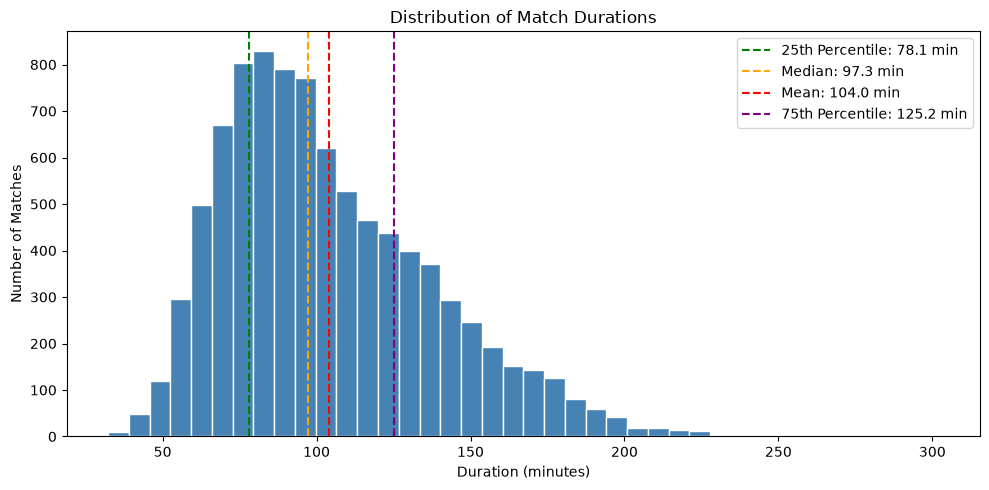

In [34]:

durations = df["total_minutes"]

q25 = durations.quantile(0.25)
q75 = durations.quantile(0.75)
mean = durations.mean()
median = durations.median()

plt.figure(figsize=(10, 5))
plt.hist(durations, bins=40, color="steelblue", edgecolor="white")

plt.axvline(q25, color="green", linestyle="--", label=f"25th Percentile: {q25:.1f} min")
plt.axvline(median, color="orange", linestyle="--", label=f"Median: {median:.1f} min")
plt.axvline(mean, color="red", linestyle="--", label=f"Mean: {mean:.1f} min")
plt.axvline(q75, color="purple", linestyle="--", label=f"75th Percentile: {q75:.1f} min")

plt.title("Distribution of Match Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Matches")
plt.legend()

plt.tight_layout()
plt.show()